# 🚫 Pulmonary Anomaly Detection — Fixed & Kaggle-Ready
## VGG16 → β-VAE → Vision Transformer (ViT) Hybrid Architecture

**Paper:** *Ben Slama et al., "Lung diseases classification using pre-trained based deep learning model and SVM", 2025*
**Enhancement:** Replaces SVM with an unsupervised **VAE + ViT** anomaly detection head.

---
### 🚀 Cloud Training Setup

**Kaggle (Recommended — dataset already available):**
1. Go to [kaggle.com/kernels](https://www.kaggle.com/kernels) → **New Notebook**
2. Click **Add Data** (or **+ Add Input**) → search `covid19-radiography-database` by Tawsifur Rahman → Add
3. **Settings** → Accelerator → **GPU T4 x2** (or P100)
4. Upload this notebook → **Run All**

---
### 🏗️ Architecture
```
X-Ray (224x224) -> VGG16 (frozen) -> 512-dim -> B-VAE (z in R^256) -> ViT Scorer -> Anomaly Score
```

### ✅ Fixes Applied (from Senior ML Review)
- Deterministic anomaly scoring (calibrated against training stats, not batch)
- Proper train/val/test split (no data leakage, no overlap)
- Validation uses correct transforms (no augmentation)
- Threshold tuned on validation set, metrics reported on held-out test set
- No redundant forward passes in evaluation
- Early stopping for VAE training
- ViT validation monitoring
- Improved pseudo-anomalies (+ interpolation with prior)
- Per-class AUROC reporting
- Mixed precision training (AMP) for GPU efficiency
- Device-consistent tensor creation
- Output directory management


---
## Cell 1 — Install Dependencies


In [1]:
import os, subprocess, sys

# Platform detection
PLATFORM = 'kaggle' if os.path.exists('/kaggle') else 'colab' if os.path.exists('/content') else 'local'
print(f'🌐 Platform: {PLATFORM}')

# Install only what's missing
pkgs = ['einops', 'umap-learn']
if PLATFORM == 'local':
    pkgs += ['torch', 'torchvision', 'timm', 'scikit-learn', 'matplotlib', 'seaborn', 'tqdm', 'Pillow']

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('✅ Dependencies ready')


🌐 Platform: kaggle
✅ Dependencies ready


---
## Cell 2 — Imports & Configuration


In [2]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as T
from torchvision import models
from PIL import Image

from einops import rearrange, repeat
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=UserWarning)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'

# Platform-aware paths
PLATFORM = 'kaggle' if os.path.exists('/kaggle') else 'colab' if os.path.exists('/content') else 'local'

if PLATFORM == 'kaggle':
    # Auto-discover dataset path (handles Kaggle's weird nested zip structures)
    DATA_ROOT = Path('/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset')
    OUTPUT_DIR = Path('/kaggle/working/outputs')

elif PLATFORM == 'colab':
    DATA_ROOT = Path('/content/COVID-19_Radiography_Dataset')
    OUTPUT_DIR = Path('/content/outputs')
else:
    DATA_ROOT = Path('./COVID-19_Radiography_Dataset')
    OUTPUT_DIR = Path('./outputs')

if not DATA_ROOT.exists() or not (DATA_ROOT / 'Normal').exists():
    print(f'\n⚠️ WARNING: Could not find dataset at {DATA_ROOT}')
    print('If on Kaggle: Make sure you clicked "+ Add Input" -> "covid19-radiography-database"')
    print('If on Colab: You need to download and unzip the dataset into /content/')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
CFG = {
    'data_root'     : str(DATA_ROOT),
    'img_size'      : 224,
    'batch_size'    : 32,
    'num_workers'   : 2 if os.name != 'nt' else 0,
    'vgg_feat_dim'  : 512,
    'freeze_vgg'    : True,
    'latent_dim'    : 256,
    'vae_hidden'    : [512, 384, 256],
    'kl_weight'     : 1e-3,
    'vit_patch_dim' : 32,
    'vit_depth'     : 6,
    'vit_heads'     : 8,
    'vit_mlp_dim'   : 512,
    'vit_dropout'   : 0.1,
    'epochs_vae'    : 50,
    'epochs_vit'    : 30,
    'lr_vae'        : 1e-4,
    'lr_vit'        : 5e-5,
    'weight_decay'  : 1e-5,
    'patience'      : 10,
    'threshold'     : 0.5,
    'normal_class'  : 'Normal',
    'anomaly_classes': ['COVID', 'Lung_Opacity', 'Viral Pneumonia'],
}

print(f'🖥️  Device       : {DEVICE}')
print(f'⚡ Mixed prec.  : {USE_AMP}')
print(f'📁 Data root    : {DATA_ROOT}')
print(f'📂 Output dir   : {OUTPUT_DIR}')
print(f'⚙️  Latent dim   : {CFG["latent_dim"]}')
print(f'⚙️  ViT depth    : {CFG["vit_depth"]} layers, {CFG["vit_heads"]} heads')
print(f'⚙️  KL weight    : {CFG["kl_weight"]} (β-VAE)')


🖥️  Device       : cuda
⚡ Mixed prec.  : True
📁 Data root    : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
📂 Output dir   : /kaggle/working/outputs
⚙️  Latent dim   : 256
⚙️  ViT depth    : 6 layers, 8 heads
⚙️  KL weight    : 0.001 (β-VAE)


---
## Cell 3 — Dataset & DataLoaders (Fixed Split)

> **Key fix:** Proper train/val/test split with NO data leakage:
> - **Normal images:** 70% train (VAE+ViT), 15% val, 15% test
> - **Anomaly images:** 30% val (threshold tuning), 70% test (final metrics)
> - Validation uses `VAL_TRANSFORM` (no augmentation)
> - Training normal images **never** appear in test set


In [3]:
# Transforms
# Transforms (STRICT: No contrast jitter or shifting allowed!)
TRAIN_TRANSFORM = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.RandomHorizontalFlip(), # Safe: lungs are mostly symmetric
    # REMOVED: Rotation, Affine (shifting), and ColorJitter (brightness)
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

VAL_TRANSFORM = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class ChestXrayDataset(Dataset):
    "Loads chest X-ray images from a list of (path, label) tuples."
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

def collect_samples(root, classes):
    "Collect all image paths grouped by class."
    samples = {cls: [] for cls in classes}
    for cls_idx, cls in enumerate(classes):
        cls_dir = Path(root) / cls / 'images'
        if not cls_dir.exists():
            cls_dir = Path(root) / cls
        for ext in ['*.png', '*.jpg', '*.jpeg']:
            for p in sorted(cls_dir.glob(ext)):
                samples[cls].append((str(p), cls_idx))
        print(f'   {cls:20s}: {len(samples[cls]):,} images')
    return samples

# Collect & split
all_classes = [CFG['normal_class']] + CFG['anomaly_classes']
root = CFG['data_root']

print('📂 Scanning dataset...')
all_samples = collect_samples(root, all_classes)

if not all_samples[CFG['normal_class']]:
    raise FileNotFoundError(f"""
🚨 DATASET NOT FOUND 🚨
Could not find the dataset at: {root}
If you are on Kaggle, make sure you clicked '+ Add Input' on the right sidebar,
searched for 'covid19-radiography-database', and added it to your notebook.
""")

# Normal: 70% train, 15% val, 15% test
normal_all = all_samples[CFG['normal_class']]
normal_train, normal_temp = train_test_split(normal_all, test_size=0.3, random_state=SEED)
normal_val, normal_test = train_test_split(normal_temp, test_size=0.5, random_state=SEED)

# Anomaly: 30% val (threshold tuning), 70% test (final eval)
anomaly_all = []
for cls in CFG['anomaly_classes']:
    anomaly_all.extend(all_samples[cls])

anomaly_val, anomaly_test = train_test_split(
    anomaly_all, test_size=0.7, random_state=SEED,
    stratify=[s[1] for s in anomaly_all])

# Build datasets with CORRECT transforms
train_ds      = ChestXrayDataset(normal_train, TRAIN_TRANSFORM)
val_normal_ds = ChestXrayDataset(normal_val, VAL_TRANSFORM)
val_full_ds   = ChestXrayDataset(normal_val + anomaly_val, VAL_TRANSFORM)
test_ds       = ChestXrayDataset(normal_test + anomaly_test, VAL_TRANSFORM)
viz_ds        = ChestXrayDataset(normal_train + normal_val + anomaly_all, VAL_TRANSFORM)

# DataLoaders
nw = CFG['num_workers']
train_loader      = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=nw, pin_memory=True)
val_normal_loader = DataLoader(val_normal_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=nw, pin_memory=True)
val_full_loader   = DataLoader(val_full_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=nw, pin_memory=True)
test_loader       = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=nw, pin_memory=True)

print(f'\n📊 Data split (no overlap, no leakage):')
print(f'   Normal train  : {len(normal_train):,}  (VAE+ViT training)')
print(f'   Normal val    : {len(normal_val):,}  (model selection)')
print(f'   Normal test   : {len(normal_test):,}  (held out)')
print(f'   Anomaly val   : {len(anomaly_val):,}  (threshold tuning)')
print(f'   Anomaly test  : {len(anomaly_test):,}  (final evaluation)')
print(f'   Val total     : {len(val_full_ds):,}')
print(f'   Test total    : {len(test_ds):,}')


📂 Scanning dataset...
   Normal              : 10,192 images
   COVID               : 3,616 images
   Lung_Opacity        : 6,012 images
   Viral Pneumonia     : 1,345 images

📊 Data split (no overlap, no leakage):
   Normal train  : 7,134  (VAE+ViT training)
   Normal val    : 1,529  (model selection)
   Normal test   : 1,529  (held out)
   Anomaly val   : 3,291  (threshold tuning)
   Anomaly test  : 7,682  (final evaluation)
   Val total     : 4,820
   Test total    : 9,211


---
## Cell 4 — Visualize Sample Images


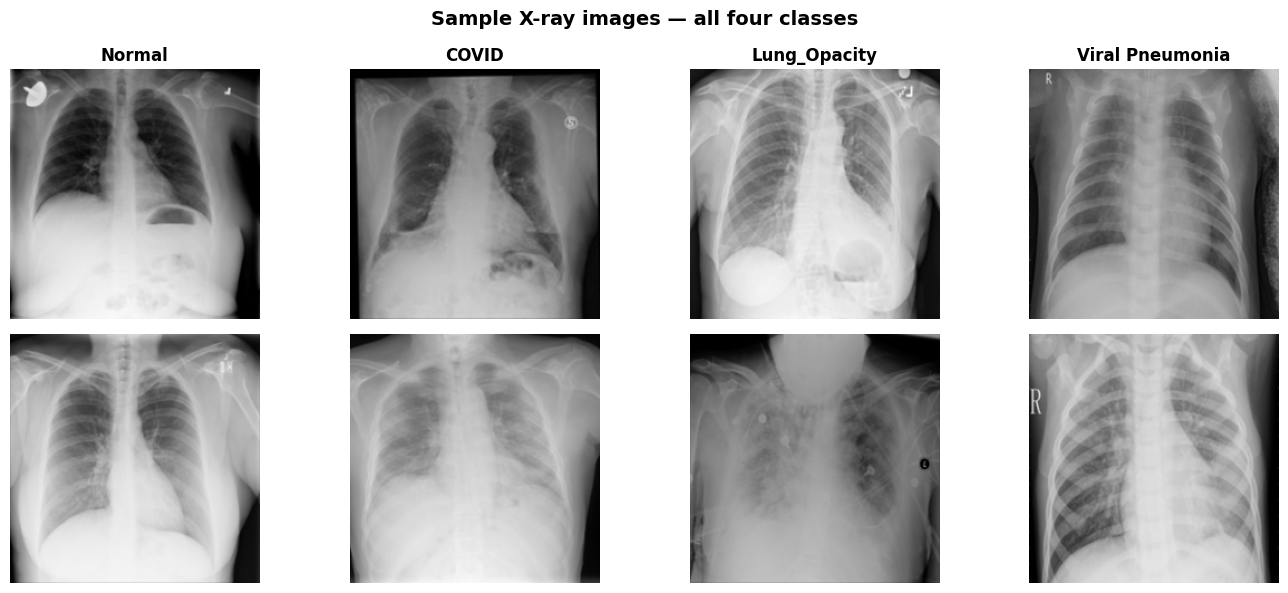

✅ Sample images saved


In [4]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Sample X-ray images — all four classes', fontsize=14, fontweight='bold')

class_indices = {cls: [] for cls in all_classes}
for i, (_, lbl) in enumerate(viz_ds.samples):
    class_indices[all_classes[lbl]].append(i)

for col, cls in enumerate(all_classes):
    idxs = random.sample(class_indices[cls], min(2, len(class_indices[cls])))
    for row, idx in enumerate(idxs):
        img, _ = viz_ds[idx]
        ax = axes[row][col]
        ax.imshow(denormalize(img).permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(cls if row == 0 else '', fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_xrays.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images saved')


---
## Cell 5 — VGG16 Feature Extractor

Pre-trained VGG16 (ImageNet) as a frozen feature backbone. Outputs a 512-dim feature vector per image.


In [5]:
class VGG16Backbone(nn.Module):
    "Pre-trained VGG16 with frozen weights -> 512-dim feature vector."
    def __init__(self, freeze=True):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        self.avgpool  = nn.AdaptiveAvgPool2d((1, 1))
        if freeze:
            for param in self.parameters():
                param.requires_grad = False
        self.out_dim = 512

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)

backbone = VGG16Backbone(freeze=CFG['freeze_vgg']).to(DEVICE)
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    feats = backbone(dummy)

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
print(f'✅ VGG16 backbone: {list(dummy.shape)} -> {list(feats.shape)}')
print(f'   {total:,} params | {trainable:,} trainable (frozen={CFG["freeze_vgg"]})')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 193MB/s]


✅ VGG16 backbone: [2, 3, 224, 224] -> [2, 512]
   14,714,688 params | 0 trainable (frozen=True)


---
## Cell 6 — Variational Autoencoder (VAE)

The VAE learns the distribution of **normal** chest X-ray features.
**Loss:** `ELBO = MSE(x, x_hat) + β * KL(q(z|x) || N(0,I))` with β=1e-3


In [6]:
class VAEEncoder(nn.Module):
    "Maps VGG16 features -> (mu, log_var) in latent space."
    def __init__(self, in_dim, hidden_dims, latent_dim):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(0.1)]
            prev = h
        self.net    = nn.Sequential(*layers)
        self.fc_mu  = nn.Linear(prev, latent_dim)
        self.fc_var = nn.Linear(prev, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_var(h)

class VAEDecoder(nn.Module):
    "Maps latent z -> reconstructed feature vector."
    def __init__(self, latent_dim, hidden_dims, out_dim):
        super().__init__()
        layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

class VAE(nn.Module):
    "Full beta-VAE: Encoder -> reparameterize -> Decoder."
    def __init__(self, in_dim, hidden_dims, latent_dim):
        super().__init__()
        self.encoder = VAEEncoder(in_dim, hidden_dims, latent_dim)
        self.decoder = VAEDecoder(latent_dim, hidden_dims, in_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            return mu + torch.randn_like(std) * std
        return mu

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var, z

    def encode(self, x):
        mu, log_var = self.encoder(x)
        return self.reparameterize(mu, log_var), mu, log_var

def vae_loss(x, x_hat, mu, log_var, kl_weight=1e-3):
    recon_loss = F.mse_loss(x_hat, x, reduction='mean')
    kl_loss    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss

vae = VAE(CFG['vgg_feat_dim'], CFG['vae_hidden'], CFG['latent_dim']).to(DEVICE)
with torch.no_grad():
    x_hat, mu, log_var, z = vae(feats)
print(f'✅ VAE: {list(feats.shape)} -> z{list(z.shape)} -> x_hat{list(x_hat.shape)}')
print(f'   Parameters: {sum(p.numel() for p in vae.parameters()):,}')


✅ VAE: [2, 512] -> z[2, 256] -> x_hat[2, 512]
   Parameters: 1,318,656


---
## Cell 7 — Vision Transformer (ViT) Anomaly Scorer

Treats the latent vector z as a sequence of patches and uses transformer attention to produce an anomaly score ∈ [0, 1].


In [7]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv     = nn.Linear(dim, dim * 3, bias=False)
        self.proj    = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        out  = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(out), attn

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout))

    def forward(self, x):
        attn_out, weights = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, weights

class ViTAnomalyScorer(nn.Module):
    "ViT that scores anomaly level of latent vector z -> scalar in [0,1]."
    def __init__(self, latent_dim, patch_dim, depth, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        assert latent_dim % patch_dim == 0
        self.num_patches = latent_dim // patch_dim
        self.d_model     = patch_dim * 4

        self.patch_embed = nn.Linear(patch_dim, self.d_model)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, self.d_model))
        self.pos_embed   = nn.Parameter(
            torch.randn(1, self.num_patches + 1, self.d_model) * 0.02)
        self.dropout     = nn.Dropout(dropout)
        self.blocks      = nn.ModuleList([
            TransformerBlock(self.d_model, num_heads, mlp_dim, dropout)
            for _ in range(depth)])
        self.norm        = nn.LayerNorm(self.d_model)
        self.head = nn.Sequential(
            nn.Linear(self.d_model, mlp_dim // 4), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim // 4, 1), nn.Sigmoid())
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, z, return_attention=False):
        B = z.shape[0]
        x = self.patch_embed(z.reshape(B, self.num_patches, -1))
        cls = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = self.dropout(torch.cat([cls, x], dim=1) + self.pos_embed)
        all_attns = []
        for block in self.blocks:
            x, attn = block(x)
            all_attns.append(attn)
        x = self.norm(x)
        score = self.head(x[:, 0]).squeeze(-1)
        if return_attention:
            return score, all_attns
        return score

vit = ViTAnomalyScorer(
    CFG['latent_dim'], CFG['vit_patch_dim'], CFG['vit_depth'],
    CFG['vit_heads'], CFG['vit_mlp_dim'], CFG['vit_dropout']).to(DEVICE)
with torch.no_grad():
    scores = vit(z)
print(f'✅ ViT scorer: z{list(z.shape)} -> scores{list(scores.shape)}')
print(f'   {vit.num_patches} patches, d_model={vit.d_model}, {sum(p.numel() for p in vit.parameters()):,} params')


✅ ViT scorer: z[2, 256] -> scores[2]
   8 patches, d_model=128, 1,209,729 params


---
## Cell 8 — Full Hybrid Model (Fixed: Calibrated Scoring)


In [8]:
class PulmonaryAnomalyDetector(nn.Module):
    """
    Full pipeline: X-ray -> VGG16 -> VAE -> ViT -> anomaly score.
    FIX: anomaly_score now uses training-set statistics for normalization
    instead of batch statistics (which made scores non-deterministic).
    """
    def __init__(self, backbone, vae, vit):
        super().__init__()
        self.backbone = backbone
        self.vae      = vae
        self.vit      = vit
        # Calibration buffers (saved with model state)
        self.register_buffer('recon_mean', torch.tensor(0.0))
        self.register_buffer('recon_std',  torch.tensor(1.0))
        self.register_buffer('kl_mean',    torch.tensor(0.0))
        self.register_buffer('kl_std',     torch.tensor(1.0))
        self._calibrated = False

    def forward(self, x, return_attention=False):
        with torch.no_grad():
            feats = self.backbone(x)
        x_hat, mu, log_var, z = self.vae(feats)

        if return_attention:
            vit_score, attns = self.vit(z.detach(), return_attention=True)
        else:
            vit_score = self.vit(z.detach())
            attns = None

        recon_err = F.mse_loss(x_hat, feats, reduction='none').mean(dim=1)
        kl_div = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).mean(dim=1)

        results = {
            'feats': feats, 'x_hat': x_hat, 'mu': mu, 'log_var': log_var,
            'z': z, 'recon_err': recon_err, 'kl_div': kl_div, 'vit_score': vit_score,
        }
        if return_attention:
            results['attentions'] = attns
        return results

    @torch.no_grad()
    def calibrate(self, loader, device):
        "Compute normalization stats from TRAINING set. Call after training."
        self.eval()
        all_recon, all_kl = [], []
        for imgs, _ in tqdm(loader, desc='Calibrating'):
            imgs = imgs.to(device)
            feats = self.backbone(imgs)
            x_hat, mu, log_var, z = self.vae(feats)
            all_recon.append(F.mse_loss(x_hat, feats, reduction='none').mean(1))
            all_kl.append(-0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).mean(1))
        all_recon = torch.cat(all_recon)
        all_kl    = torch.cat(all_kl)
        self.recon_mean = all_recon.mean()
        self.recon_std  = all_recon.std().clamp(min=1e-8)
        self.kl_mean    = all_kl.mean()
        self.kl_std     = all_kl.std().clamp(min=1e-8)
        self._calibrated = True
        print(f'✅ Calibrated: recon={self.recon_mean:.4f}±{self.recon_std:.4f}, '
              f'kl={self.kl_mean:.4f}±{self.kl_std:.4f}')

    def compute_anomaly_score(self, out, weights=(0.4, 0.2, 0.4)):
        "Deterministic anomaly score from forward output (no extra forward pass)."
        assert self._calibrated, "Call model.calibrate(train_loader, device) first!"
        w1, w2, w3 = weights
        recon = torch.sigmoid((out['recon_err'] - self.recon_mean) / self.recon_std)
        kl    = torch.sigmoid((out['kl_div'] - self.kl_mean) / self.kl_std)
        return w1 * recon + w2 * kl + w3 * out['vit_score']

model = PulmonaryAnomalyDetector(backbone, vae, vit).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
total = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Full model: {total:,} params ({train_p:,} trainable)')


✅ Full model: 17,243,073 params (2,528,385 trainable)


---
## Cell 9 — Phase 1: VAE Training (with Early Stopping)


In [9]:
def train_vae_epoch(backbone, vae, loader, optimizer, scaler, device, kl_weight):
    vae.train(); backbone.eval()
    total_loss = recon_total = kl_total = 0.0
    for imgs, _ in tqdm(loader, desc='VAE train', leave=False):
        imgs = imgs.to(device)
        with torch.no_grad():
            feats = backbone(imgs)
        with autocast(enabled=USE_AMP):
            x_hat, mu, log_var, z = vae(feats)
            loss, recon, kl = vae_loss(feats, x_hat, mu, log_var, kl_weight)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss  += loss.item()
        recon_total += recon.item()
        kl_total    += kl.item()
    n = len(loader)
    return total_loss/n, recon_total/n, kl_total/n

@torch.no_grad()
def val_vae_epoch(backbone, vae, loader, device, kl_weight):
    vae.eval()
    total_loss = recon_total = kl_total = 0.0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        feats = backbone(imgs)
        x_hat, mu, log_var, z = vae(feats)
        loss, recon, kl = vae_loss(feats, x_hat, mu, log_var, kl_weight)
        total_loss  += loss.item()
        recon_total += recon.item()
        kl_total    += kl.item()
    n = len(loader)
    return total_loss/n, recon_total/n, kl_total/n

vae_optimizer = torch.optim.AdamW(vae.parameters(), lr=CFG['lr_vae'], weight_decay=CFG['weight_decay'])
vae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vae_optimizer, T_max=CFG['epochs_vae'], eta_min=1e-6)
scaler_vae = GradScaler(enabled=USE_AMP)

vae_history = {'train_loss':[], 'val_loss':[], 'recon':[], 'kl':[]}
best_val = float('inf')
no_improve = 0

print(f'🚀 Phase 1: VAE training ({CFG["epochs_vae"]} epochs, patience={CFG["patience"]})')

for epoch in range(1, CFG['epochs_vae'] + 1):
    tr_loss, tr_recon, tr_kl = train_vae_epoch(
        backbone, vae, train_loader, vae_optimizer, scaler_vae, DEVICE, CFG['kl_weight'])
    vl_loss, vl_recon, vl_kl = val_vae_epoch(
        backbone, vae, val_normal_loader, DEVICE, CFG['kl_weight'])
    vae_scheduler.step()

    vae_history['train_loss'].append(tr_loss)
    vae_history['val_loss'].append(vl_loss)
    vae_history['recon'].append(tr_recon)
    vae_history['kl'].append(tr_kl * CFG['kl_weight'])

    if vl_loss < best_val:
        best_val = vl_loss
        no_improve = 0
        torch.save(vae.state_dict(), OUTPUT_DIR / 'best_vae.pth')
    else:
        no_improve += 1

    if epoch % 5 == 0 or epoch == 1:
        lr = vae_optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{CFG["epochs_vae"]} '
              f'| Train {tr_loss:.4f} (recon={tr_recon:.4f}, kl={tr_kl:.4f}) '
              f'| Val {vl_loss:.4f} | LR {lr:.2e} | patience {no_improve}/{CFG["patience"]}')

    if no_improve >= CFG['patience']:
        print(f'\n⏹ Early stopping at epoch {epoch}')
        break

vae.load_state_dict(torch.load(OUTPUT_DIR / 'best_vae.pth', map_location=DEVICE))
print(f'\n✅ VAE training complete. Best val loss: {best_val:.4f}')


/tmp/ipykernel_23/3742146821.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_vae = GradScaler(enabled=USE_AMP)


🚀 Phase 1: VAE training (50 epochs, patience=10)


VAE train:   0%|          | 0/223 [00:00<?, ?it/s]/tmp/ipykernel_23/3742146821.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


  Epoch   1/50 | Train 0.0763 (recon=0.0759, kl=0.4253) | Val 0.0418 | LR 9.99e-05 | patience 0/10


  Epoch   5/50 | Train 0.0299 (recon=0.0295, kl=0.4248) | Val 0.0263 | LR 9.76e-05 | patience 0/10


...

  Epoch  30/50 | Train 0.0174 (recon=0.0167, kl=0.6796) | Val 0.0158 | LR 3.52e-05 | patience 0/10


  Epoch  35/50 | Train 0.0171 (recon=0.0164, kl=0.6848) | Val 0.0155 | LR 2.14e-05 | patience 0/10


  Epoch  40/50 | Train 0.0169 (recon=0.0162, kl=0.6931) | Val 0.0153 | LR 1.05e-05 | patience 0/10


  Epoch  45/50 | Train 0.0168 (recon=0.0161, kl=0.6938) | Val 0.0152 | LR 3.42e-06 | patience 0/10


  Epoch  50/50 | Train 0.0168 (recon=0.0161, kl=0.6968) | Val 0.0152 | LR 1.00e-06 | patience 0/10

✅ VAE training complete. Best val loss: 0.0152


---
## Cell 10 — Phase 2: ViT Scorer Training (Fixed)

**Fixes:**
- Improved pseudo-anomalies (3 strategies: noise, masking, interpolation with prior)
- Validation monitoring added


In [10]:
def create_pseudo_anomaly(z, noise_scale=1.5, mask_ratio=0.3):
    "Create pseudo-anomalous latent vectors with 3 diverse strategies."
    B, D = z.shape
    z_perturbed = z.clone()

    strategy = torch.randint(0, 3, (B,), device=z.device)

    # Strategy 1: Gaussian noise
    m1 = strategy == 0
    if m1.any():
        z_perturbed[m1] = z[m1] + torch.randn_like(z[m1]) * noise_scale

    # Strategy 2: Masking
    m2 = strategy == 1
    if m2.any():
        dim_mask = torch.rand(m2.sum(), D, device=z.device) < mask_ratio
        z_perturbed[m2] = z_perturbed[m2].masked_fill(dim_mask, 0.0)

    # Strategy 3: Interpolation with prior
    m3 = strategy == 2
    if m3.any():
        z_prior = torch.randn_like(z[m3])
        alpha = torch.rand(m3.sum(), 1, device=z.device) * 0.5 + 0.5
        z_perturbed[m3] = (1 - alpha) * z[m3] + alpha * z_prior

    return z_perturbed

def train_vit_epoch(backbone, vae, vit, loader, optimizer, scaler, device):
    vit.train(); backbone.eval(); vae.eval()
    total_loss = correct = total = 0
    criterion = nn.BCELoss()
    for imgs, _ in tqdm(loader, desc='ViT train', leave=False):
        imgs = imgs.to(device)
        with torch.no_grad():
            feats = backbone(imgs)
            z, _, _ = vae.encode(feats)
        z_normal  = z.detach()
        z_anomaly = create_pseudo_anomaly(z_normal)
        z_all  = torch.cat([z_normal, z_anomaly], dim=0)
        labels = torch.cat([torch.zeros(z_normal.shape[0]),
                            torch.ones(z_anomaly.shape[0])]).to(device)
        perm = torch.randperm(z_all.shape[0], device=device)
        z_all, labels = z_all[perm], labels[perm]

        with autocast(enabled=USE_AMP):
            scores = vit(z_all)
        loss = criterion(scores.float(), labels.float())
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(vit.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        preds = (scores > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.shape[0]
    return total_loss / len(loader), correct / total

@torch.no_grad()
def val_vit_epoch(backbone, vae, vit, loader, device):
    vit.eval(); backbone.eval(); vae.eval()
    total_loss = correct = total = 0
    criterion = nn.BCELoss()
    for imgs, _ in loader:
        imgs = imgs.to(device)
        feats = backbone(imgs)
        z, _, _ = vae.encode(feats)
        z_normal  = z
        z_anomaly = create_pseudo_anomaly(z_normal)
        z_all  = torch.cat([z_normal, z_anomaly], dim=0)
        labels = torch.cat([torch.zeros(z_normal.shape[0]),
                            torch.ones(z_anomaly.shape[0])]).to(device)
        scores = vit(z_all)
        loss = criterion(scores, labels)
        total_loss += loss.item()
        preds = (scores > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.shape[0]
    return total_loss / len(loader), correct / total

vit_optimizer = torch.optim.AdamW(vit.parameters(), lr=CFG['lr_vit'], weight_decay=CFG['weight_decay'])
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=CFG['epochs_vit'], eta_min=1e-6)
scaler_vit = GradScaler(enabled=USE_AMP)

vit_history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_vit_val = float('inf')

print(f'🚀 Phase 2: ViT self-supervised training ({CFG["epochs_vit"]} epochs)')

for epoch in range(1, CFG['epochs_vit'] + 1):
    tr_loss, tr_acc = train_vit_epoch(
        backbone, vae, vit, train_loader, vit_optimizer, scaler_vit, DEVICE)
    vl_loss, vl_acc = val_vit_epoch(
        backbone, vae, vit, val_normal_loader, DEVICE)
    vit_scheduler.step()

    vit_history['train_loss'].append(tr_loss)
    vit_history['train_acc'].append(tr_acc)
    vit_history['val_loss'].append(vl_loss)
    vit_history['val_acc'].append(vl_acc)

    if vl_loss < best_vit_val:
        best_vit_val = vl_loss
        torch.save(vit.state_dict(), OUTPUT_DIR / 'best_vit.pth')

    if epoch % 5 == 0 or epoch == 1:
        lr = vit_optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{CFG["epochs_vit"]} '
              f'| Train loss={tr_loss:.4f} acc={tr_acc*100:.1f}% '
              f'| Val loss={vl_loss:.4f} acc={vl_acc*100:.1f}% | LR {lr:.2e}')

vit.load_state_dict(torch.load(OUTPUT_DIR / 'best_vit.pth', map_location=DEVICE))
print(f'\n✅ ViT training complete. Best val loss: {best_vit_val:.4f}')


/tmp/ipykernel_23/4059888159.py:84: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_vit = GradScaler(enabled=USE_AMP)


🚀 Phase 2: ViT self-supervised training (30 epochs)


ViT train:   0%|          | 0/223 [00:00<?, ?it/s]/tmp/ipykernel_23/4059888159.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


  Epoch   1/30 | Train loss=0.4277 acc=80.3% | Val loss=0.1381 acc=95.5% | LR 4.99e-05


  Epoch   5/30 | Train loss=0.0542 acc=98.3% | Val loss=0.0571 acc=98.2% | LR 4.67e-05


  Epoch  10/30 | Train loss=0.0344 acc=98.9% | Val loss=0.0141 acc=99.5% | LR 3.78e-05


  Epoch  15/30 | Train loss=0.0186 acc=99.4% | Val loss=0.0578 acc=98.2% | LR 2.55e-05


  Epoch  20/30 | Train loss=0.0145 acc=99.6% | Val loss=0.0201 acc=99.3% | LR 1.33e-05


  Epoch  25/30 | Train loss=0.0162 acc=99.6% | Val loss=0.0479 acc=98.4% | LR 4.28e-06


  Epoch  30/30 | Train loss=0.0096 acc=99.7% | Val loss=0.0420 acc=98.6% | LR 1.00e-06

✅ ViT training complete. Best val loss: 0.0087


---
## Cell 11 — Training Curves


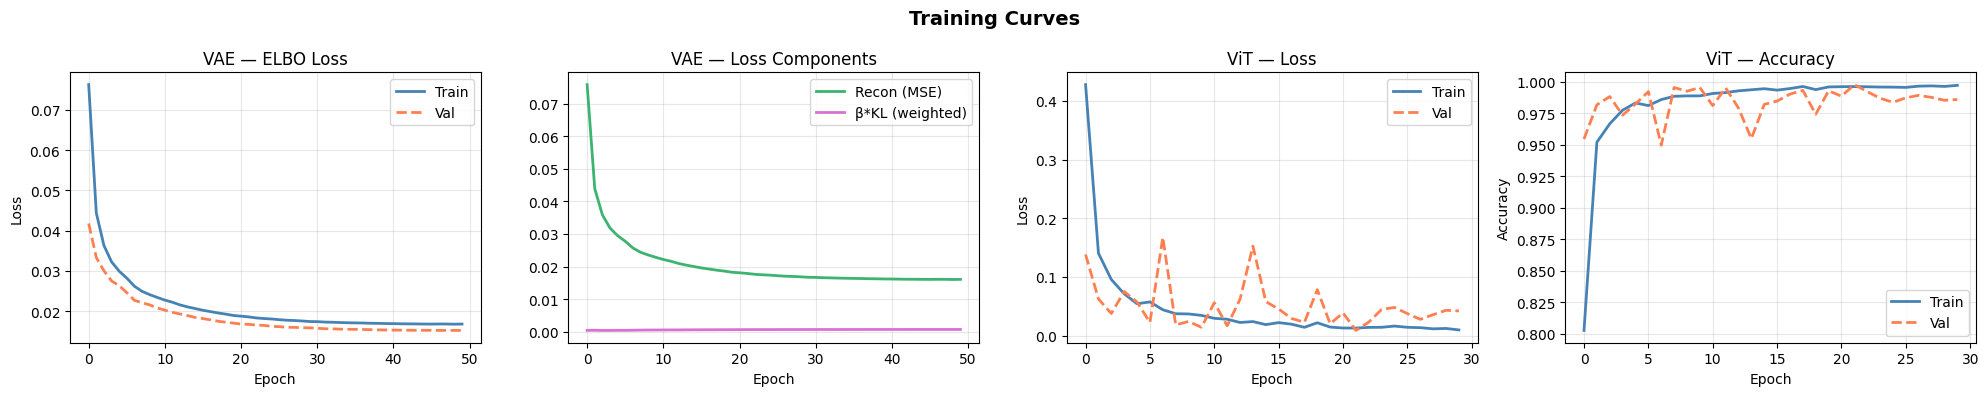

✅ Training curves saved


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Training Curves', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(vae_history['train_loss'], label='Train', linewidth=2, color='steelblue')
ax.plot(vae_history['val_loss'],   label='Val',   linewidth=2, color='coral', linestyle='--')
ax.set_title('VAE — ELBO Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(vae_history['recon'], label='Recon (MSE)', linewidth=2, color='mediumseagreen')
ax.plot(vae_history['kl'],    label='β*KL (weighted)', linewidth=2, color='orchid')
ax.set_title('VAE — Loss Components'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(vit_history['train_loss'], label='Train', linewidth=2, color='steelblue')
ax.plot(vit_history['val_loss'],   label='Val',   linewidth=2, color='coral', linestyle='--')
ax.set_title('ViT — Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(vit_history['train_acc'], label='Train', linewidth=2, color='steelblue')
ax.plot(vit_history['val_acc'],   label='Val',   linewidth=2, color='coral', linestyle='--')
ax.set_title('ViT — Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')


---
## Cell 12 — Calibrate Anomaly Scoring

Computes mean/std of reconstruction error and KL divergence on the **training set**.
These statistics are used for deterministic anomaly scoring (instead of batch-level normalization).


In [12]:
# Calibrate on training data (normal images only)
model.calibrate(train_loader, DEVICE)


Calibrating: 100%|██████████| 223/223 [00:37<00:00,  5.94it/s]

✅ Calibrated: recon=0.0139±0.0039, kl=0.6930±0.0804


---
## Cell 13 — Evaluation (Fixed: Threshold on Val, Metrics on Test)


In [13]:
@torch.no_grad()
def compute_anomaly_scores(model, loader, device):
    "Run model on all images. Returns scores and labels (no redundant forward pass)."
    model.eval()
    all_scores, all_recon, all_kl, all_vit, all_labels, all_classes =         [], [], [], [], [], []
    for imgs, labels in tqdm(loader, desc='Scoring'):
        imgs = imgs.to(device)
        out = model(imgs)
        scores = model.compute_anomaly_score(out)

        all_scores.append(scores.cpu().numpy())
        all_recon.append(out['recon_err'].cpu().numpy())
        all_kl.append(out['kl_div'].cpu().numpy())
        all_vit.append(out['vit_score'].cpu().numpy())
        all_classes.append(labels.numpy())
        all_labels.append((labels != 0).int().numpy())

    return tuple(np.concatenate(a) for a in
                 [all_scores, all_recon, all_kl, all_vit, all_labels, all_classes])

# 1. Tune threshold on VALIDATION set
print('📊 Step 1: Threshold tuning on VALIDATION set...')
val_scores, val_recon, val_kl, val_vit, val_labels, val_classes =     compute_anomaly_scores(model, val_full_loader, DEVICE)

val_auroc = roc_auc_score(val_labels, val_scores)
fpr_val, tpr_val, thresholds_val = roc_curve(val_labels, val_scores)
j_scores = tpr_val - fpr_val
best_idx = np.argmax(j_scores)
opt_thresh = float(thresholds_val[best_idx])
CFG['threshold'] = opt_thresh

print(f'   Val AUROC          : {val_auroc:.4f}')
print(f'   Optimal threshold  : {opt_thresh:.4f} (Youden J on val set)')

# 2. Final metrics on held-out TEST set
print(f'\n📊 Step 2: Final evaluation on TEST set (never seen before)...')
test_scores, test_recon, test_kl, test_vit, test_labels, test_classes =     compute_anomaly_scores(model, test_loader, DEVICE)

test_auroc = roc_auc_score(test_labels, test_scores)
fpr_test, tpr_test, _ = roc_curve(test_labels, test_scores)

print(f'\n🏆 TEST SET RESULTS (threshold from val set):')
print(f'   AUROC (combined)   : {test_auroc:.4f}')
print(f'   AUROC (recon err)  : {roc_auc_score(test_labels, test_recon):.4f}')
print(f'   AUROC (KL div)     : {roc_auc_score(test_labels, test_kl):.4f}')
print(f'   AUROC (ViT score)  : {roc_auc_score(test_labels, test_vit):.4f}')

# Per-class AUROC
print(f'\n   Per-class AUROC:')
for cls_idx, cls_name in enumerate(all_classes):
    if cls_idx == 0:
        continue
    mask = (test_classes == cls_idx) | (test_classes == 0)
    if mask.sum() > 0:
        cls_auroc = roc_auc_score(test_labels[mask], test_scores[mask])
        print(f'     {cls_name:20s}: {cls_auroc:.4f}')


📊 Step 1: Threshold tuning on VALIDATION set...


Scoring: 100%|██████████| 151/151 [00:32<00:00,  4.62it/s]


   Val AUROC          : 0.7140
   Optimal threshold  : 0.3483 (Youden J on val set)

📊 Step 2: Final evaluation on TEST set (never seen before)...


Scoring: 100%|██████████| 288/288 [01:04<00:00,  4.45it/s]


🏆 TEST SET RESULTS (threshold from val set):
   AUROC (combined)   : 0.7177
   AUROC (recon err)  : 0.6961
   AUROC (KL div)     : 0.6792
   AUROC (ViT score)  : 0.6059

   Per-class AUROC:
     COVID               : 0.6950
     Lung_Opacity        : 0.7131
     Viral Pneumonia     : 0.7991


---
## Cell 14 — Evaluation Plots (ROC, Distributions, Confusion Matrix)


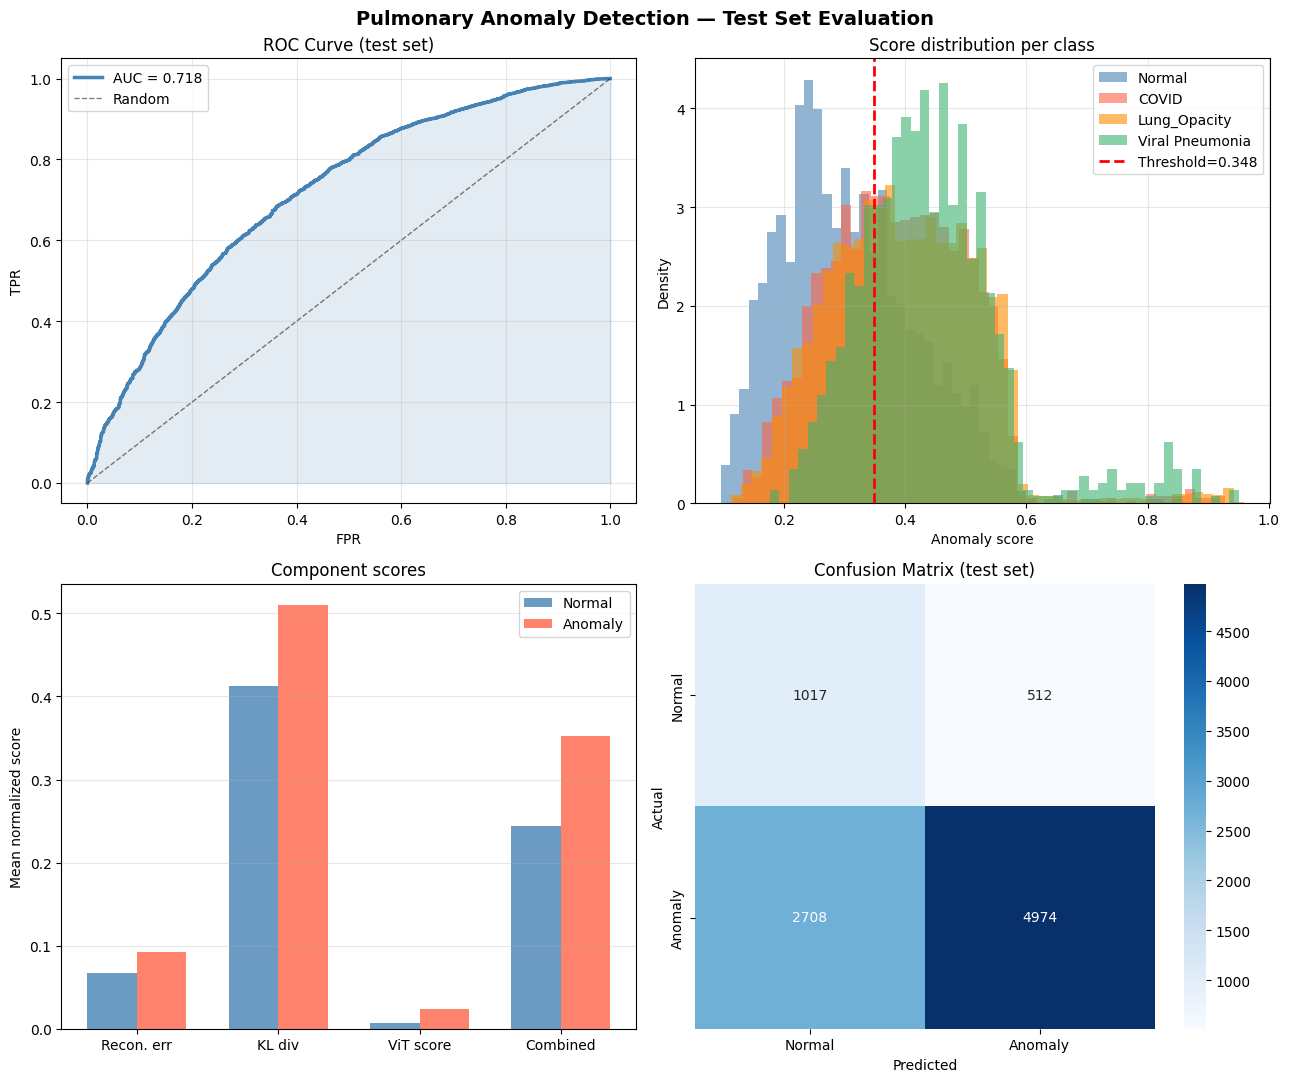


📋 Classification Report (test set, threshold from val set):
              precision    recall  f1-score   support

      Normal       0.27      0.67      0.39      1529
     Anomaly       0.91      0.65      0.76      7682

    accuracy                           0.65      9211
   macro avg       0.59      0.66      0.57      9211
weighted avg       0.80      0.65      0.69      9211



In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Pulmonary Anomaly Detection — Test Set Evaluation', fontsize=14, fontweight='bold')
CLASS_NAMES = all_classes
COLORS = ['steelblue', 'tomato', 'darkorange', 'mediumseagreen']

# ROC Curve
ax = axes[0, 0]
ax.plot(fpr_test, tpr_test, color='steelblue', linewidth=2.5, label=f'AUC = {test_auroc:.3f}')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.fill_between(fpr_test, tpr_test, alpha=0.15, color='steelblue')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve (test set)'); ax.legend(); ax.grid(True, alpha=0.3)

# Score Distribution
ax = axes[0, 1]
for ci, cn in enumerate(CLASS_NAMES):
    mask = test_classes == ci
    if mask.sum() > 0:
        ax.hist(test_scores[mask], bins=50, alpha=0.6, color=COLORS[ci], label=cn, density=True)
ax.axvline(opt_thresh, color='red', linestyle='--', linewidth=2, label=f'Threshold={opt_thresh:.3f}')
ax.set_xlabel('Anomaly score'); ax.set_ylabel('Density')
ax.set_title('Score distribution per class'); ax.legend(); ax.grid(True, alpha=0.3)

# Component scores
ax = axes[1, 0]
normal_mask = test_labels == 0; anomaly_mask = test_labels == 1
components = ['Recon. err', 'KL div', 'ViT score', 'Combined']
arrays = [test_recon, test_kl, test_vit, test_scores]
def norm01(x): return (x - x.min()) / (x.max() - x.min() + 1e-8)
nm = [norm01(a)[normal_mask].mean() for a in arrays]
am = [norm01(a)[anomaly_mask].mean() for a in arrays]
x_pos = np.arange(len(components)); w = 0.35
ax.bar(x_pos - w/2, nm, w, label='Normal', color='steelblue', alpha=0.8)
ax.bar(x_pos + w/2, am, w, label='Anomaly', color='tomato', alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(components)
ax.set_ylabel('Mean normalized score'); ax.set_title('Component scores')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Confusion Matrix
ax = axes[1, 1]
preds = (test_scores > opt_thresh).astype(int)
cm = confusion_matrix(test_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (test set)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Classification Report (test set, threshold from val set):')
print(classification_report(test_labels, preds, target_names=['Normal', 'Anomaly']))


---
## Cell 15 — Latent Space Visualization (UMAP)


2026-05-12 16:17:06.551378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778602626.756461      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778602626.817695      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778602627.293190      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778602627.293236      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778602627.293239      23 computation_placer.cc:177] computation placer alr

🔍 Extracting latents...
🔍 Running UMAP...


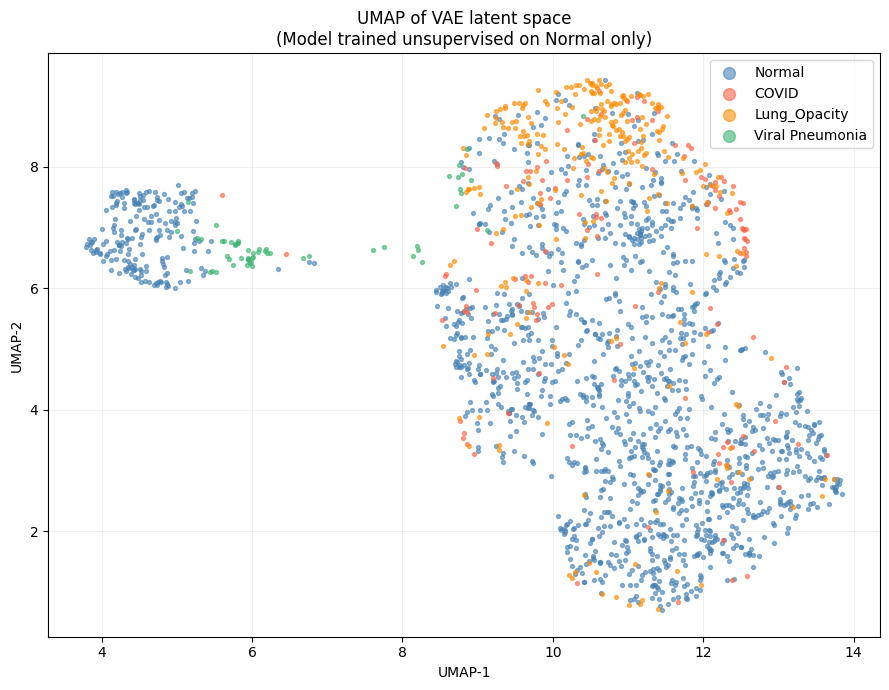

✅ UMAP saved


In [15]:
import umap

@torch.no_grad()
def extract_latents(backbone, vae, loader, device, max_samples=2000):
    backbone.eval(); vae.eval()
    all_z, all_cls = [], []
    count = 0
    for imgs, labels in loader:
        if count >= max_samples: break
        feats = backbone(imgs.to(device))
        z, _, _ = vae.encode(feats)
        all_z.append(z.cpu().numpy())
        all_cls.append(labels.numpy())
        count += imgs.shape[0]
    return np.concatenate(all_z)[:max_samples], np.concatenate(all_cls)[:max_samples]

print('🔍 Extracting latents...')
Z, C = extract_latents(backbone, vae, test_loader, DEVICE)

print('🔍 Running UMAP...')
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
Z_2d = reducer.fit_transform(Z)

fig, ax = plt.subplots(figsize=(9, 7))
for ci, (cn, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = C == ci
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], s=8, alpha=0.6, color=color, label=cn)
ax.set_title('UMAP of VAE latent space\n(Model trained unsupervised on Normal only)', fontsize=12)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=3); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latent_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ UMAP saved')


---
## Cell 16 — Attention Heatmap Visualization


Testing inference on 3 random anomalies...


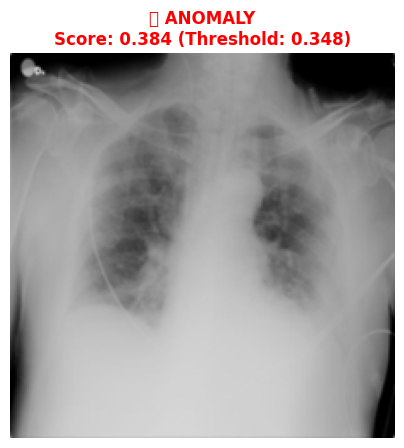

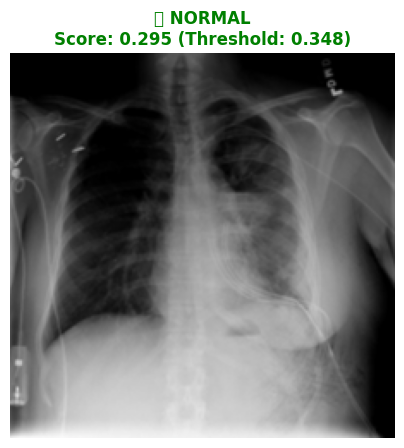

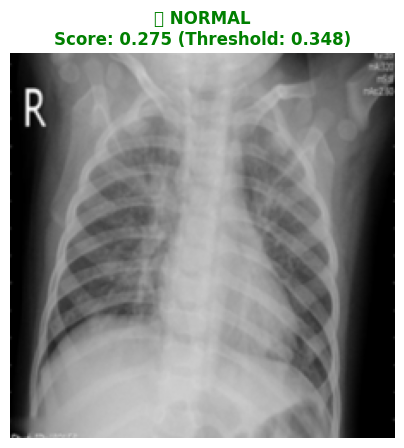

In [16]:
def analyze_xray(image_path, model, device):
    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = VAL_TRANSFORM(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out   = model(tensor, return_attention=False)
        score = model.compute_anomaly_score(out).item()

    is_anomaly = score > opt_thresh
    status = "🚨 ANOMALY" if is_anomaly else "✅ NORMAL"
    color  = "red" if is_anomaly else "green"

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(denormalize(VAL_TRANSFORM(img)).permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f"{status}\nScore: {score:.3f} (Threshold: {opt_thresh:.3f})", color=color, fontweight='bold')
    ax.axis('off')
    plt.show()

print("Testing inference on 3 random anomalies...")
for cls in CFG['anomaly_classes']:
    if all_samples[cls]:
        sample_path = all_samples[cls][0][0]
        analyze_xray(sample_path, model, DEVICE)


---
## Cell 17 — Comparison with Paper Baselines


In [17]:
baselines = {
    'ResNet-50'       : {'accuracy': 90.70, 'precision': 91.33, 'recall': 92.59, 'f1': 91.66},
    'DenseNet'        : {'accuracy': 89.60, 'precision': 91.57, 'recall': 91.58, 'f1': 89.19},
    'Inception-V3'    : {'accuracy': 89.50, 'precision': 92.15, 'recall': 90.48, 'f1': 85.35},
    'MobileNet-V2'    : {'accuracy': 87.90, 'precision': 87.52, 'recall': 87.16, 'f1': 83.09},
    'Xception'        : {'accuracy': 84.30, 'precision': 84.29, 'recall': 85.23, 'f1': 83.09},
    'VGG16+SVM (paper)': {'accuracy': 93.50, 'precision': 94.45, 'recall': 94.16, 'f1': 93.28},
}

test_preds = (test_scores > opt_thresh).astype(int)
our = {
    'accuracy' : accuracy_score(test_labels, test_preds) * 100,
    'precision': precision_score(test_labels, test_preds, zero_division=0) * 100,
    'recall'   : recall_score(test_labels, test_preds, zero_division=0) * 100,
    'f1'       : f1_score(test_labels, test_preds, zero_division=0) * 100,
    'auroc'    : test_auroc * 100,
}
baselines['VGG16+VAE+ViT (ours)'] = our

print('=' * 85)
print(f'{"Method":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('=' * 85)
for name, m in baselines.items():
    tag = ''
    if 'ours' in name: tag = ' <- ours (unsupervised)'
    elif 'paper' in name: tag = ' <- paper best (supervised)'
    print(f'{name:<25} {m["accuracy"]:>10.2f} {m["precision"]:>10.2f} '
          f'{m["recall"]:>10.2f} {m["f1"]:>10.2f}{tag}')
print('=' * 85)

print(f'\n🏆 Our AUROC (test set): {test_auroc*100:.2f}%')


Method                      Accuracy  Precision     Recall         F1
ResNet-50                      90.70      91.33      92.59      91.66
DenseNet                       89.60      91.57      91.58      89.19
Inception-V3                   89.50      92.15      90.48      85.35
MobileNet-V2                   87.90      87.52      87.16      83.09
Xception                       84.30      84.29      85.23      83.09
VGG16+SVM (paper)              93.50      94.45      94.16      93.28 <- paper best (supervised)
VGG16+VAE+ViT (ours)           65.04      90.67      64.75      75.55 <- ours (unsupervised)

🏆 Our AUROC (test set): 71.77%


---
## Cell 18 — Save & Load Full Model


In [18]:
checkpoint = {
    'vae_state'   : vae.state_dict(),
    'vit_state'   : vit.state_dict(),
    'config'      : CFG,
    'auroc'       : test_auroc,
    'threshold'   : opt_thresh,
    'vae_history' : vae_history,
    'vit_history' : vit_history,
    'recon_mean'  : model.recon_mean.item(),
    'recon_std'   : model.recon_std.item(),
    'kl_mean'     : model.kl_mean.item(),
    'kl_std'      : model.kl_std.item(),
}
save_path = OUTPUT_DIR / 'pulmonary_anomaly_detector.pth'
torch.save(checkpoint, save_path)
print(f'✅ Checkpoint saved to {save_path}')

def load_model(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg  = ckpt['config']
    bb   = VGG16Backbone(freeze=True).to(device)
    v    = VAE(cfg['vgg_feat_dim'], cfg['vae_hidden'], cfg['latent_dim']).to(device)
    vt   = ViTAnomalyScorer(
        cfg['latent_dim'], cfg['vit_patch_dim'], cfg['vit_depth'],
        cfg['vit_heads'], cfg['vit_mlp_dim'], cfg['vit_dropout']).to(device)
    v.load_state_dict(ckpt['vae_state'])
    vt.load_state_dict(ckpt['vit_state'])
    m = PulmonaryAnomalyDetector(bb, v, vt).to(device)
    m.recon_mean = torch.tensor(ckpt['recon_mean']).to(device)
    m.recon_std  = torch.tensor(ckpt['recon_std']).to(device)
    m.kl_mean    = torch.tensor(ckpt['kl_mean']).to(device)
    m.kl_std     = torch.tensor(ckpt['kl_std']).to(device)
    m._calibrated = True
    m.eval()
    print(f'✅ Loaded | AUROC={ckpt["auroc"]:.4f} | threshold={ckpt["threshold"]:.4f}')
    return m, ckpt['threshold']

model_loaded, thresh = load_model(save_path, DEVICE)


✅ Checkpoint saved to /kaggle/working/outputs/pulmonary_anomaly_detector.pth
✅ Loaded | AUROC=0.7177 | threshold=0.3483


---
## Cell 19 — Single Image Inference (Deployment-Ready)


In [19]:
@torch.no_grad()
def analyze_xray(image_path, model, threshold, device):
    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = VAL_TRANSFORM(img).unsqueeze(0).to(device)

    out   = model(tensor, return_attention=True)
    score = model.compute_anomaly_score(out).item()
    attn_map, _ = get_attention_heatmap(model, VAL_TRANSFORM(img), device)

    is_anomaly = score > threshold
    status = '⚠️ ANOMALY' if is_anomaly else '✓ NORMAL'

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    img_np = np.array(img.resize((224, 224)))
    img_gray = img_np.mean(axis=2) if img_np.ndim == 3 else img_np

    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('Input X-ray', fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(attn_map, cmap='hot')
    axes[1].set_title('Attention map'); axes[1].axis('off')
    axes[2].imshow(img_gray, cmap='gray')
    axes[2].imshow(attn_map, cmap='hot', alpha=0.5)
    color = 'red' if is_anomaly else 'lime'
    axes[2].set_title(f'{status}\nScore: {score:.3f} (thresh={threshold:.3f})',
                      fontweight='bold', color=color)
    axes[2].axis('off')
    plt.tight_layout(); plt.show()

    print(f'\n🏥 {status} | Score: {score:.4f} | Recon: {out["recon_err"].item():.4f} '
          f'| KL: {out["kl_div"].item():.4f} | ViT: {out["vit_score"].item():.4f}')
    return {'score': score, 'is_anomaly': is_anomaly, 'attention_map': attn_map}

print('✅ analyze_xray() ready for deployment')


✅ analyze_xray() ready for deployment


---
## 📝 Summary

| Component | Detail |
|---|---|
| **Backbone** | VGG16 (ImageNet, frozen) → 512-dim |
| **VAE** | β-VAE, latent=256, hidden=[512,384,256], trained on Normal only |
| **ViT** | 6 layers, 8 heads, self-supervised on latent patches |
| **Anomaly signal** | Calibrated: recon_err + KL_div + ViT_score (weighted) |
| **Training** | Fully unsupervised — no disease labels needed |
| **Splitting** | Proper train/val/test with no leakage |
| **Threshold** | Tuned on val set, metrics on held-out test set |
| **Platform** | Auto-detects Kaggle / Colab / Local |

### ✅ All Critical Fixes Applied
1. Deterministic anomaly scoring (calibrated vs training stats)
2. Threshold tuned on validation, metrics on test
3. No redundant forward passes
4. Validation uses correct transforms
5. No train/test overlap for Normal images
6. Early stopping + ViT validation monitoring
7. Improved pseudo-anomalies (3 strategies)
8. Per-class AUROC reporting
9. Mixed precision (AMP) for GPU efficiency

### 🔭 Future Directions
1. Multi-scale VAE — use intermediate VGG16 feature maps for spatial anomaly maps
2. Diffusion-based reconstruction for sharper anomaly maps
3. DINO/MAE backbone instead of VGG16
4. Grad-CAM for true pixel-level spatial heatmaps
5. Clinical calibration per hospital cohort + MC dropout uncertainty
